In [1]:
import numpy as np 
import pandas as pd 
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, Normalizer, RobustScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, LassoCV, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score




pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', None)

# Ignorer tous les avertissements (utilisez avec précaution)
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('Data_Modelisation-3.csv')
df.Vitesse = df.Vitesse.astype(str)

X_o = df.drop(['Moyenne CFL F','Glissement',"hauteur (mm)"], axis=1)
#X_o["descritisation"] = X_o['Moyenne G% [%]'].apply(descritisation)
#y = df['Moyenne CFL C']

### Analyse par chaque contaminant:

In [4]:
# Neige fraiche (B)
nfb = X_o[X_o.Contaminant == 'Neige fraiche (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Neige fraiche (G)
nfg = X_o[X_o.Contaminant == 'Neige fraiche (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (G)
ncg = X_o[X_o.Contaminant == 'N.C. (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (B)
ncb = X_o[X_o.Contaminant == 'N.C. (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# NC.C.
ncc = X_o[X_o.Contaminant == 'NC.C.'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Verglas
ver = X_o[X_o.Contaminant == 'Verglas'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# DRY
dry = X_o[X_o.Contaminant == 'DRY'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Glace
gla = X_o[X_o.Contaminant == 'Glace'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# SLUSH
slh = X_o[X_o.Contaminant == 'SLUSH'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Columns to drop in every modele


In [5]:
l=[nfb, nfg, ncg, ncb, ncc, ver, dry, gla, slh]
names = ['nfb', 'nfg', 'ncg', 'ncb', 'ncc', 'ver', 'dry', 'gla', 'slh']
Contaminant = ['Neige fraiche (B)', 'Neige fraiche (G)', 'N.C. (G)', 'N.C. (B)', 'NC.C.', 'Verglas', 'DRY', 'Glace', 'SLUSH']
dict = {"Contaminant" : Contaminant, "Nombre d'observation" : list(map(lambda x: x.shape[0], l)), "Nombre des colonnes" : [6]*9}
pd.DataFrame(dict).sort_values(["Nombre d'observation"], ascending = False).reset_index(drop = True)

,Contaminant,Nombre d'observation,Nombre des colonnes
0,NC.C.,232,6
1,Neige fraiche (B),194,6
2,N.C. (B),140,6
3,Neige fraiche (G),129,6
4,Glace,115,6
5,N.C. (G),109,6
6,SLUSH,78,6
7,Verglas,58,6
8,DRY,19,6


## Data Preprocessing

In [6]:
def scale_encode(x,y = 0):
    encoder = OneHotEncoder(drop='first')
    # Séparer les variables qualitatives et numériques
    qualitative_vars = ['Vitesse']
    numeric_vars = x.select_dtypes(include=['float']).columns.tolist()
    
    # Appliquer le one-hot encoding aux variables qualitatives
    encoded_vars = encoder.fit_transform(x[qualitative_vars]).toarray()
    encoded_columns = encoder.get_feature_names_out(qualitative_vars)
    encoded_df = pd.DataFrame(encoded_vars, columns=encoded_columns)
    if y == 1:  # Appliquer le StandardScaler aux variables numériques
        scaler = StandardScaler().set_output(transform='pandas')
    elif y == 2:  # Appliquer le Normalizer aux variables numériques
        scaler = Normalizer().set_output(transform='pandas')
    else:
        X = pd.concat([x.drop(['Vitesse'], axis=1), encoded_df], axis=1)
        return X
    
    # Appliquer le scaler et transformer les variables numériques
    scaled_df = scaler.fit_transform(x[numeric_vars])
    
    # Concaténation des DataFrames encodé et standardisé
    X = pd.concat([scaled_df, encoded_df], axis=1)
    return X

In [7]:
# Bla bla bla
one_hot_encoder = OneHotEncoder(sparse=False).set_output(transform='pandas')
encoded_df = one_hot_encoder.fit_transform(df[['Vitesse']])

# Display the resulting DataFrame
#print(encoded_df)

### Fonctions utiles

In [8]:
def coef(X, regressor):
    y_pred = regressor.predict(X_test)
    y_pred_train = regressor.predict(X_train)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = (y_test-y_pred).abs().mean()
    
    mse_train = mean_squared_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)
    mae_train = (y_train-y_pred_train).abs().mean()
    
    
    
    print(f"Pour le test: RMSE = {round((np.sqrt(mse)),5)}, R² = {round(r2*100,2)}, MAE = {round(mae,5)}")
    print(f"Pour le train: RMSE = {round((np.sqrt(mse_train)),5)}, R² = {round(r2_train*100,2)}, MAE = {round(mae_train,5)}")
    coefficients = regressor.coef_
    intercept = regressor.intercept_
    features = X.columns
    
    coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})
    coef_df['Coefficient'] = coef_df['Coefficient'].apply(lambda x: f"{x:.6f}")
    
    print(coef_df)
    print(f"Intercept: {intercept:.4f}")

## Neige fraiche (B) (173 observations)

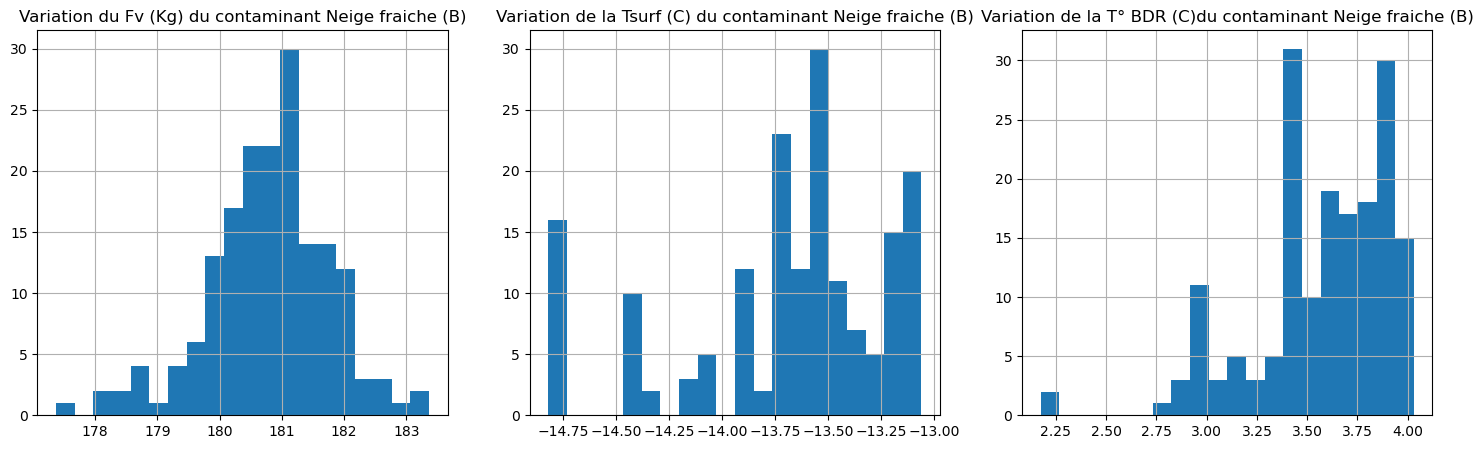

In [9]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
nfb['Fv (kg)'].hist(bins=20)
plt.title('Variation du Fv (Kg) du contaminant Neige fraiche (B)')
plt.subplot(1,3,2)

nfb['Tsurf (C)'].hist(bins=20)
plt.title('Variation de la Tsurf (C) du contaminant Neige fraiche (B)')
plt.subplot(1,3,3)
nfb['T° BDR (C)'].hist(bins=20)
plt.title('Variation de la T° BDR (C)du contaminant Neige fraiche (B)')
plt.show()


Les physiciens soutiennent que la masse, la température de surface et celle de la bande de roulement n'ont pas un impact significatif sur la variation du CFL C.  
En outre, d'apres les trois graphes précedents, on peut ajouter que ces trois variables présentent une faible variabilité pour ce contaminant. Par conséquent, les inclure dans un modèle, notamment de régression linéaire, rendrait celui-ci plus complexe et augmenterait le risque de surapprentissage.

### Modélisation linèaire sans transformation polynomiale

In [10]:
%%time
X = nfb.drop(['Moyenne CFL C'], axis=1)
X = scale_encode(X)
y= nfb['Moyenne CFL C']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = X.Vitesse_65, random_state=123)
regressor = LinearRegression()
regressor.fit(X_train, y_train)


coef(X, regressor)

Pour le test: RMSE = 0.02656, R² = 45.44, MAE = 0.02108
Pour le train: RMSE = 0.02577, R² = 33.71, MAE = 0.01976
          Feature Coefficient
0  Moyenne G% [%]   -0.000060
1         Fv (kg)   -0.000229
2       Tsurf (C)    0.010077
3      T° BDR (C)    0.042837
4      Vitesse_65   -0.012638
Intercept: 0.1732
CPU times: total: 46.9 ms
Wall time: 88 ms


### Ajout de coeft deg >1

In [11]:
def descritisation_nfb(x):
    if x< 6:
        return "8"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"

In [12]:
X = nfb.drop(['Moyenne CFL C','Fv (kg)',"T° BDR (C)", "Tsurf (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_nfb)

X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)


X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']




y= nfb['Moyenne CFL C']

stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = stratify_combined, random_state=96)
regressor = LinearRegression()
regressor.fit(X_train, y_train)
        
        
coef(X, regressor)

Pour le test: RMSE = 0.01472, R² = 81.31, MAE = 0.01166
Pour le train: RMSE = 0.02183, R² = 55.07, MAE = 0.0151
          Feature Coefficient
0  Moyenne G% [%]   -0.007236
1          log(g)    0.072213
2      Vitesse_65   -0.021446
3              g2    0.000044
4             g*V    0.000442
Intercept: 0.0695


In [13]:
y.describe()

count    173.000000
mean       0.135485
std        0.033088
min        0.029524
25%        0.116238
50%        0.138381
75%        0.157143
max        0.214524
Name: Moyenne CFL C, dtype: float64

### Commentaire 

Dans ce qui suit, on va commenter les resultats ci-dessus, premierement on va commencer par le choit de la transformation sur les données, et pourquoi c'est esentielle surtout sur ce type de donnée, on va après passer au resultat de cette regression linèaire:
La standardisation des données met les caractéristiques sur une échelle commune, améliorant la performance des algorithmes sensibles aux échelles. Elle accélère la convergence des modèles d'apprentissage. Cela rend les caractéristiques comparables. Par exemple dans les tableaux ci-dessus, pour l'observation 65, avant la transformation on avait des valeurs 100 pour le glissmemnt, 181 pour Fv, -13 et 3 pour les deux températures, à l'aide de ces variables, il faut construire une equation pour expliquer le CFLC qui est dans l'intervalle [0,1] (0.1 pour l'observation 65), alors suremment on va attribuer des valeurs tres petites au variables (surtout si on integre des valeurs polynomiales dans le modeles), dans ce cas une valeur tres minime ne signifie pas une faible contribution de la variable mais s'explique par le grand echelle de la variable (on peut imaginer l'integration du carré du glissement pour la meme observation (65) on va avoir une valeur de 10000 !!! cette valeur doit expliquer un coeft entre 0 et 1 !!)



Pour savoir la contribution d'une variable dans le modèle on fixe les autres variables et on derive par rapport à cette variable, voir la feuille

## Neige fraiche (G) (129 observations)

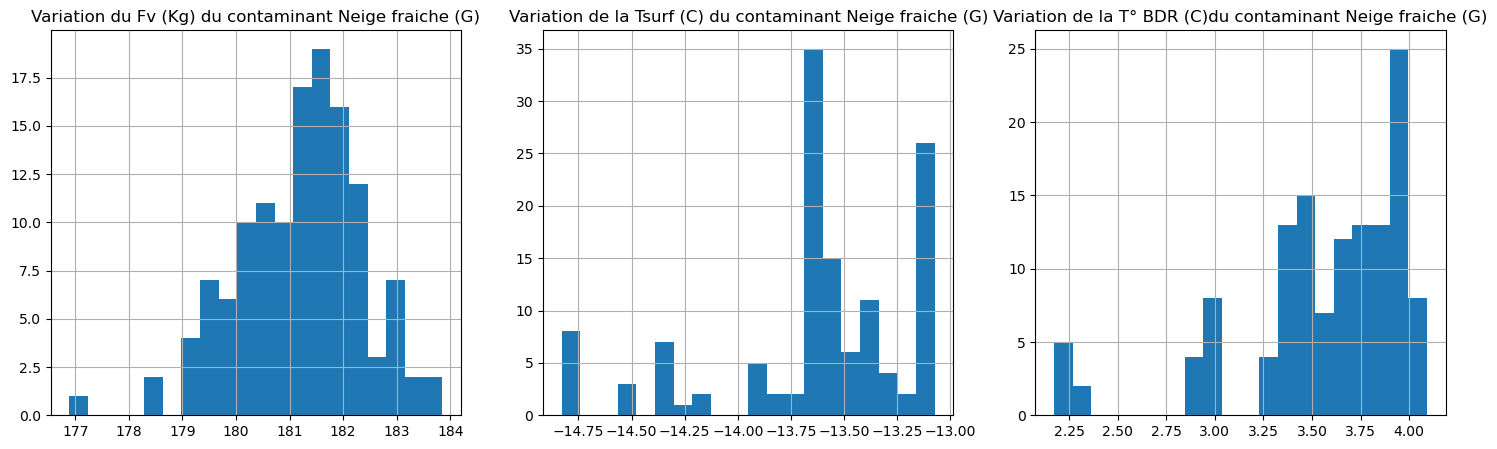

In [14]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
nfg['Fv (kg)'].hist(bins=20)
plt.title('Variation du Fv (Kg) du contaminant Neige fraiche (G)')
plt.subplot(1,3,2)

nfg['Tsurf (C)'].hist(bins=20)
plt.title('Variation de la Tsurf (C) du contaminant Neige fraiche (G)')
plt.subplot(1,3,3)
nfg['T° BDR (C)'].hist(bins=20)
plt.title('Variation de la T° BDR (C)du contaminant Neige fraiche (G)')
plt.show()


### Modélisation linèaire sans transformation polynomiale

In [15]:
%%time
X = nfg.drop(['Moyenne CFL C'], axis=1)
X = scale_encode(X,0)
y= nfg['Moyenne CFL C']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = X.Vitesse_65, random_state=123)
regressor = LinearRegression()
regressor.fit(X_train, y_train)


coef(X, regressor)

Pour le test: RMSE = 0.02539, R² = 59.34, MAE = 0.01795
Pour le train: RMSE = 0.026, R² = 52.29, MAE = 0.01875
          Feature Coefficient
0  Moyenne G% [%]    0.000156
1         Fv (kg)    0.002529
2       Tsurf (C)    0.014783
3      T° BDR (C)    0.052655
4      Vitesse_65   -0.001121
Intercept: -0.3184
CPU times: total: 31.2 ms
Wall time: 36 ms


### Ajout de coeft deg >1

In [16]:
def descritisation_nfg(x):
    if x<3:
        return "3"
    elif x< 6:
        return "6"
    elif x< 9:
        return "9"
    elif x< 13:
        return "13"
    elif x< 16:
        return "16"
    else:
        return "more"

In [17]:
X = nfg.drop(['Moyenne CFL C','Fv (kg)',"T° BDR (C)","Tsurf (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_nfg)

X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)

#X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']

stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)


y= nfg['Moyenne CFL C']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = stratify_combined, random_state=20)#7 20 29 70 84 555
regressor = LinearRegression()
regressor.fit(X_train, y_train)
    
    
coef(X, regressor)


Pour le test: RMSE = 0.0097, R² = 94.18, MAE = 0.00795
Pour le train: RMSE = 0.01402, R² = 86.34, MAE = 0.01117
          Feature Coefficient
0  Moyenne G% [%]   -0.001718
1          log(g)    0.050074
2      Vitesse_65   -0.017036
3             g*V    0.000386
Intercept: 0.0645


In [18]:
y.describe()

count    129.000000
mean       0.129334
std        0.038565
min        0.022619
25%        0.113429
50%        0.136476
75%        0.153857
max        0.200952
Name: Moyenne CFL C, dtype: float64

## N.C. (G) (111 observations)

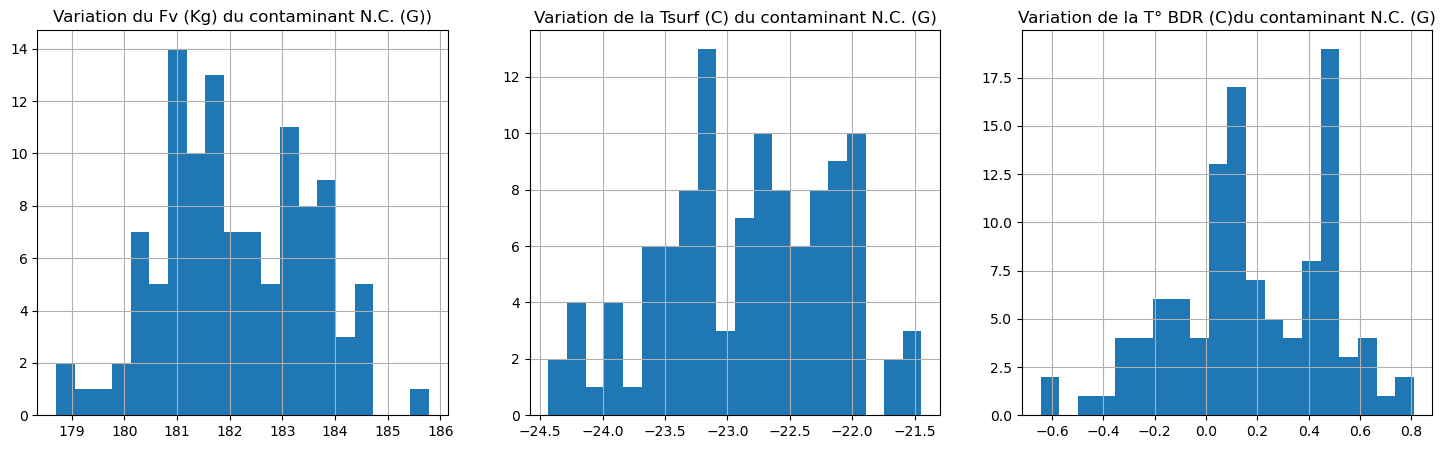

In [19]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
ncg['Fv (kg)'].hist(bins=20)
plt.title('Variation du Fv (Kg) du contaminant N.C. (G))')
plt.subplot(1,3,2)

ncg['Tsurf (C)'].hist(bins=20)
plt.title('Variation de la Tsurf (C) du contaminant N.C. (G)')
plt.subplot(1,3,3)
ncg['T° BDR (C)'].hist(bins=20)
plt.title('Variation de la T° BDR (C)du contaminant N.C. (G)')
plt.show()

### Modélisation linèaire sans transformation polynomiale

In [20]:
%%time
X = ncg.drop(['Moyenne CFL C'], axis=1)
X = scale_encode(X,1)
y= ncg['Moyenne CFL C']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = X.Vitesse_65, random_state=42)
regressor = LinearRegression()
regressor.fit(X_train, y_train)


coef(X, regressor)

Pour le test: RMSE = 0.05622, R² = -4.52, MAE = 0.04391
Pour le train: RMSE = 0.05558, R² = 15.74, MAE = 0.04419
          Feature Coefficient
0  Moyenne G% [%]    0.007644
1         Fv (kg)   -0.008069
2       Tsurf (C)    0.009199
3      T° BDR (C)    0.016029
4      Vitesse_65    0.028940
Intercept: 0.1427
CPU times: total: 31.2 ms
Wall time: 37.3 ms


### Ajout de coeft deg >1

In [21]:
def descritisation_ncg(x):
    if x<2:
        return "2"
    elif x< 5:
        return "5"
    elif x< 9:
        return "9"
    elif x< 12:
        return "12"
    elif x< 15:
        return "15"
    elif x< 17:
        return "17"
    else:
        return "more"

In [22]:
X = ncg.drop(['Moyenne CFL C','Fv (kg)',"T° BDR (C)","Tsurf (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_ncg)

X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X)

X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']


stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)


y= ncg['Moyenne CFL C']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify = stratify_combined, random_state=78)
regressor = LinearRegression()
regressor.fit(X_train, y_train)
    
    
coef(X, regressor)

Pour le test: RMSE = 0.01824, R² = 88.08, MAE = 0.01531
Pour le train: RMSE = 0.027, R² = 80.5, MAE = 0.0208
          Feature Coefficient
0  Moyenne G% [%]    0.001455
1          log(g)    0.055287
2      Vitesse_65   -0.033989
3              g2   -0.000032
4             g*V    0.000656
Intercept: 0.0610


In [23]:
y.describe()

count    111.000000
mean       0.156160
std        0.059799
min        0.018952
25%        0.127881
50%        0.172238
75%        0.193905
max        0.255762
Name: Moyenne CFL C, dtype: float64

## N.C. (B) (141 observations)

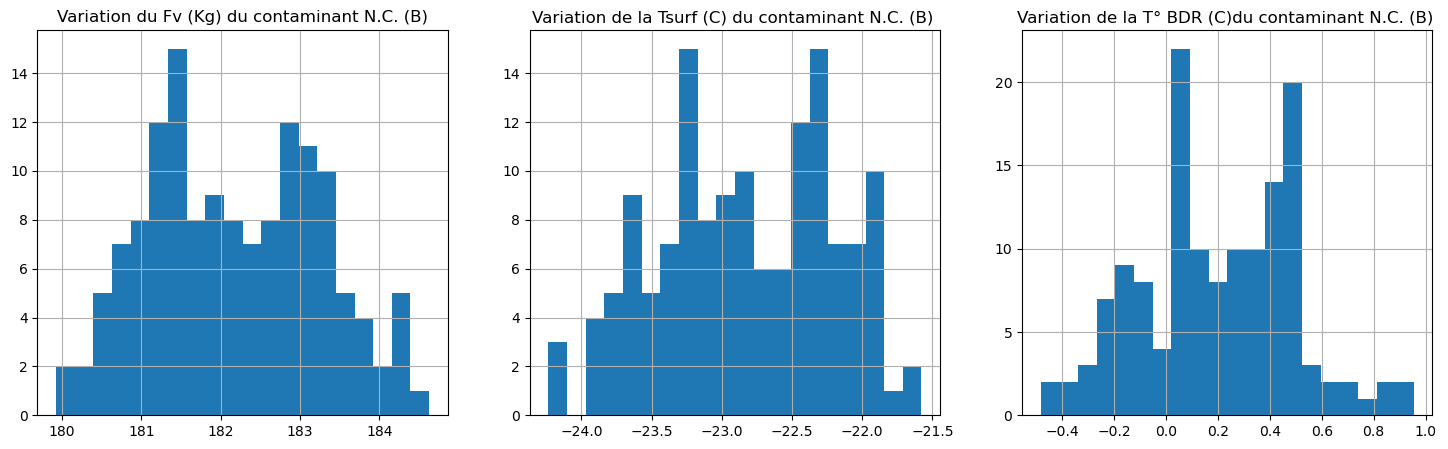

In [24]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
ncb['Fv (kg)'].hist(bins=20)
plt.title('Variation du Fv (Kg) du contaminant N.C. (B)')
plt.subplot(1,3,2)

ncb['Tsurf (C)'].hist(bins=20)
plt.title('Variation de la Tsurf (C) du contaminant N.C. (B) ')
plt.subplot(1,3,3)
ncb['T° BDR (C)'].hist(bins=20)
plt.title('Variation de la T° BDR (C)du contaminant N.C. (B) ')
plt.show()

### Modélisation linèaire sans transformation polynomiale

In [25]:
%%time
X = ncb.drop(['Moyenne CFL C'], axis=1)
X = scale_encode(X,1)
y= ncb['Moyenne CFL C']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = X.Vitesse_65, random_state=123)
regressor = LinearRegression()
regressor.fit(X_train, y_train)


coef(X, regressor)

Pour le test: RMSE = 0.06165, R² = -21.92, MAE = 0.04724
Pour le train: RMSE = 0.04927, R² = 20.06, MAE = 0.03914
          Feature Coefficient
0  Moyenne G% [%]   -0.009074
1         Fv (kg)    0.005463
2       Tsurf (C)    0.025067
3      T° BDR (C)    0.008804
4      Vitesse_65    0.015781
Intercept: 0.1549
CPU times: total: 31.2 ms
Wall time: 24.9 ms


### Ajout de coeft deg >1

In [26]:
def descritisation_ncb(x):
    if x<2:
        return "2"
    elif x< 6:
        return "6"
    elif x< 9:
        return "9"
    elif x< 13:
        return "13"
    elif x< 16:
        return "16"
    else:
        return "more"

In [27]:
X = ncb.drop(['Moyenne CFL C','Fv (kg)',"T° BDR (C)","Tsurf (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_ncb)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)

X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']

stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)


y= ncb['Moyenne CFL C']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify = stratify_combined, random_state=15)#3 15 51 62 96
regressor = LinearRegression()
regressor.fit(X_train, y_train)
    
    
coef(X, regressor)

Pour le test: RMSE = 0.01398, R² = 91.9, MAE = 0.01187
Pour le train: RMSE = 0.02157, R² = 85.59, MAE = 0.01754
          Feature Coefficient
0  Moyenne G% [%]    0.002944
1          log(g)    0.048450
2      Vitesse_65   -0.010601
3              g2   -0.000044
4             g*V    0.000344
Intercept: 0.0641


In [28]:
y.describe()

count    141.000000
mean       0.164351
std        0.055576
min        0.018095
25%        0.130619
50%        0.171476
75%        0.205095
max        0.254571
Name: Moyenne CFL C, dtype: float64

## NC.C. (238 observations)

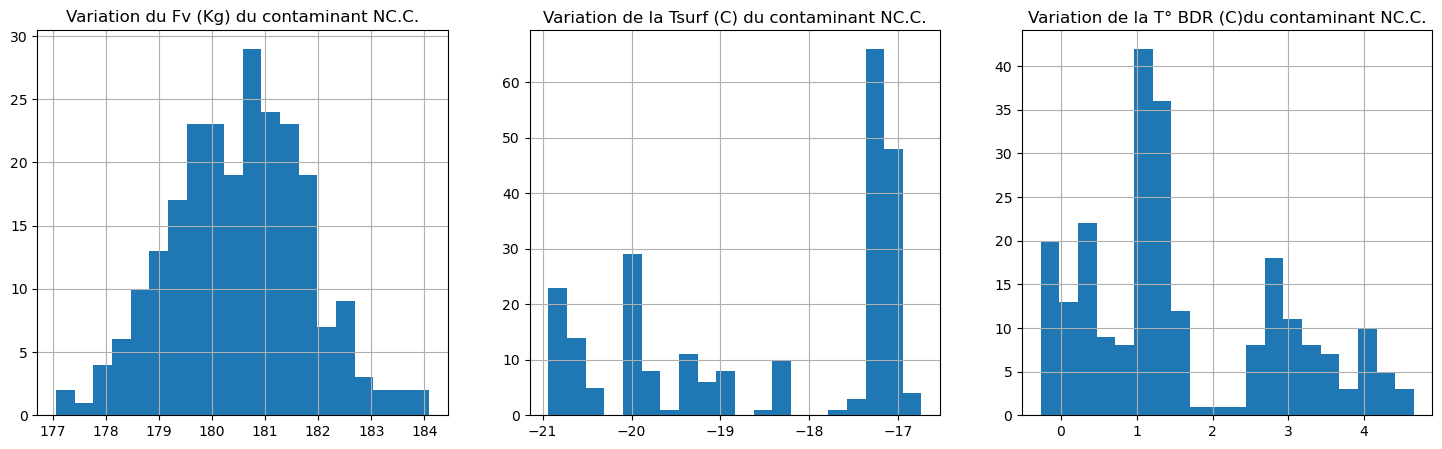

In [29]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
ncc['Fv (kg)'].hist(bins=20)
plt.title('Variation du Fv (Kg) du contaminant NC.C.')
plt.subplot(1,3,2)

ncc['Tsurf (C)'].hist(bins=20)
plt.title('Variation de la Tsurf (C) du contaminant NC.C.')
plt.subplot(1,3,3)
ncc['T° BDR (C)'].hist(bins=20)
plt.title('Variation de la T° BDR (C)du contaminant NC.C.')
plt.show()

### Modélisation linèaire sans transformation polynomiale

In [30]:
%%time
X = ncc.drop(['Moyenne CFL C'], axis=1)
X = scale_encode(X,)
y= ncc['Moyenne CFL C']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = X.Vitesse_65, random_state=42)
regressor = LinearRegression()
regressor.fit(X_train, y_train)


coef(X, regressor)

Pour le test: RMSE = 0.04474, R² = 28.08, MAE = 0.03663
Pour le train: RMSE = 0.04503, R² = 27.71, MAE = 0.03453
          Feature Coefficient
0  Moyenne G% [%]   -0.000469
1         Fv (kg)    0.001609
2       Tsurf (C)   -0.025715
3      T° BDR (C)    0.026132
4      Vitesse_65    0.008937
Intercept: -0.5999
CPU times: total: 31.2 ms
Wall time: 28.5 ms


### Ajout de coeft deg >1

In [31]:
def descritisation_ncc(x):
    if x<2:
        return "2"
    if x<4:
        return "4"
    if x<6:
        return "6"
    elif x< 8:
        return "8"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"

In [32]:
X = ncc.drop(['Moyenne CFL C','Fv (kg)',"T° BDR (C)","Tsurf (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_ncc)

# X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)

X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']
X["g3"] = X['Moyenne G% [%]']**3

stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)



y= ncc['Moyenne CFL C']    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify = stratify_combined, random_state=16)#16 55 64 70 81
regressor = LinearRegression()
regressor.fit(X_train, y_train)
    
    
coef(X, regressor)

Pour le test: RMSE = 0.02648, R² = 73.17, MAE = 0.01978
Pour le train: RMSE = 0.03054, R² = 67.35, MAE = 0.02312
          Feature Coefficient
0  Moyenne G% [%]    0.024936
1      Vitesse_65   -0.009270
2              g2   -0.001086
3              g3    0.000009
Intercept: 0.0912


In [33]:
y.describe()

count    238.000000
mean       0.196023
std        0.053104
min        0.011667
25%        0.165071
50%        0.203833
75%        0.235643
max        0.280667
Name: Moyenne CFL C, dtype: float64

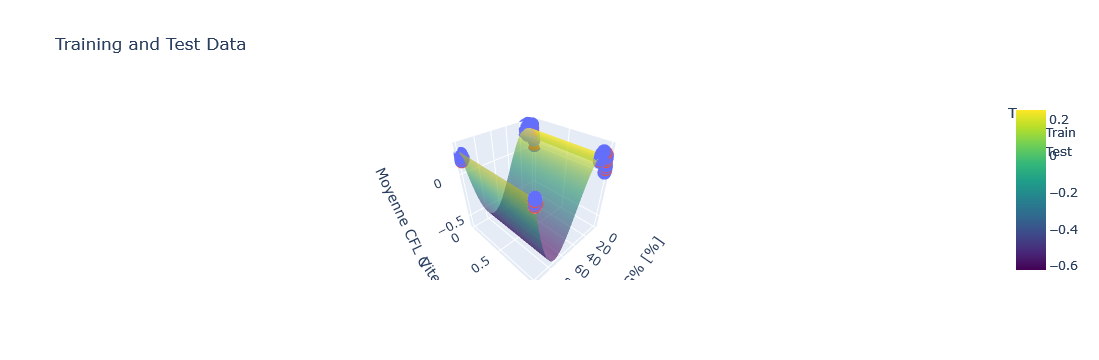

In [34]:
def scale_encode(x, y=0):
    encoder = OneHotEncoder(drop='first')
    # Séparer les variables qualitatives et numériques
    qualitative_vars = ['Vitesse']
    
    # Vérifier si les variables qualitatives sont dans le DataFrame
    if any(col not in x.columns for col in qualitative_vars):
        encoded_df = pd.DataFrame(index=x.index)  # Crée un DataFrame vide avec le même index
    else:
        # Appliquer le one-hot encoding aux variables qualitatives
        encoded_vars = encoder.fit_transform(x[qualitative_vars]).toarray()
        encoded_columns = encoder.get_feature_names_out(qualitative_vars)
        encoded_df = pd.DataFrame(encoded_vars, columns=encoded_columns, index=x.index)
    
    numeric_vars = x.select_dtypes(include=['float64', 'int64']).columns.tolist()
    
    if y == 1:  # Appliquer le StandardScaler aux variables numériques
        scaler = StandardScaler().set_output(transform='pandas')
    elif y == 2:  # Appliquer le Normalizer aux variables numériques
        scaler = Normalizer().set_output(transform='pandas')
    else:
        X = pd.concat([x.drop(qualitative_vars, axis=1, errors='ignore'), encoded_df], axis=1)
        return X
    
    # Appliquer le scaler et transformer les variables numériques
    scaled_df = scaler.fit_transform(x[numeric_vars])
    
    # Concaténation des DataFrames encodé et standardisé
    X = pd.concat([scaled_df, encoded_df], axis=1)
    return X









import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Préparation des données
X = ncc.drop(['Moyenne CFL C', 'Fv (kg)', "T° BDR (C)", "Tsurf (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_ncc)
n=2
#X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)

X["g2"] = X['Moyenne G% [%]'] ** 2
X["g3"] = X['Moyenne G% [%]'] ** 3

#X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']

stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)

y = ncc['Moyenne CFL C']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=stratify_combined, random_state=42)

# Entraîner le modèle de régression linéaire
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Choisissez deux variables indépendantes pour la visualisation 3D
feature_1 = 'Moyenne G% [%]'
feature_2 = 'Vitesse_65'

# Créez une grille de valeurs pour les variables indépendantes
x1_range = np.linspace(X[feature_1].min(), X[feature_1].max(), 100)
x2_range = np.linspace(X[feature_2].min(), X[feature_2].max(), 100)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# Construire la grille de données avec toutes les caractéristiques nécessaires
X_grid = pd.DataFrame({
    feature_1: x1_grid.ravel(),
    feature_2: x2_grid.ravel()
})

# Ajouter les caractéristiques supplémentaires
#X_grid["log(g)"] = np.log(X_grid[feature_1])
X_grid["g2"] = X_grid[feature_1] ** 2
X_grid["g3"] = X_grid[feature_1] ** 3

# X_grid["g*V"] = X_grid[feature_1] * X_grid[feature_2]

# Appliquer l'encodage et le scaling nécessaires
X_grid_transformed = scale_encode(X_grid, 0)

# Réorganiser les colonnes de X_grid_transformed pour correspondre à l'ordre des colonnes de X_train
X_grid_transformed = X_grid_transformed[X_train.columns]

# Utilisez le modèle pour prédire y sur la grille
y_pred_grid = regressor.predict(X_grid_transformed).reshape(x1_grid.shape)

# Préparez les données pour la visualisation 3D avec plotly.express
df_viz_train = pd.DataFrame({
    feature_1: X_train[feature_1],
    feature_2: X_train[feature_2],
    'Moyenne CFL C': y_train,
    'Type': 'Train'
})

df_viz_test = pd.DataFrame({
    feature_1: X_test[feature_1],
    feature_2: X_test[feature_2],
    'Moyenne CFL C': y_test,
    'Type': 'Test'
})

df_viz = pd.concat([df_viz_train, df_viz_test])

fig = px.scatter_3d(df_viz, x=feature_1, y=feature_2, z='Moyenne CFL C', color='Type', title='Training and Test Data')

# Ajoutez la surface de régression avec plotly.graph_objects
fig.add_trace(go.Surface(
    x=x1_grid,
    y=x2_grid,
    z=y_pred_grid,
    colorscale='Viridis',
    opacity=0.6,
    name='Regression Plane'
))

fig.show()


## Verglas (60 observations) ..


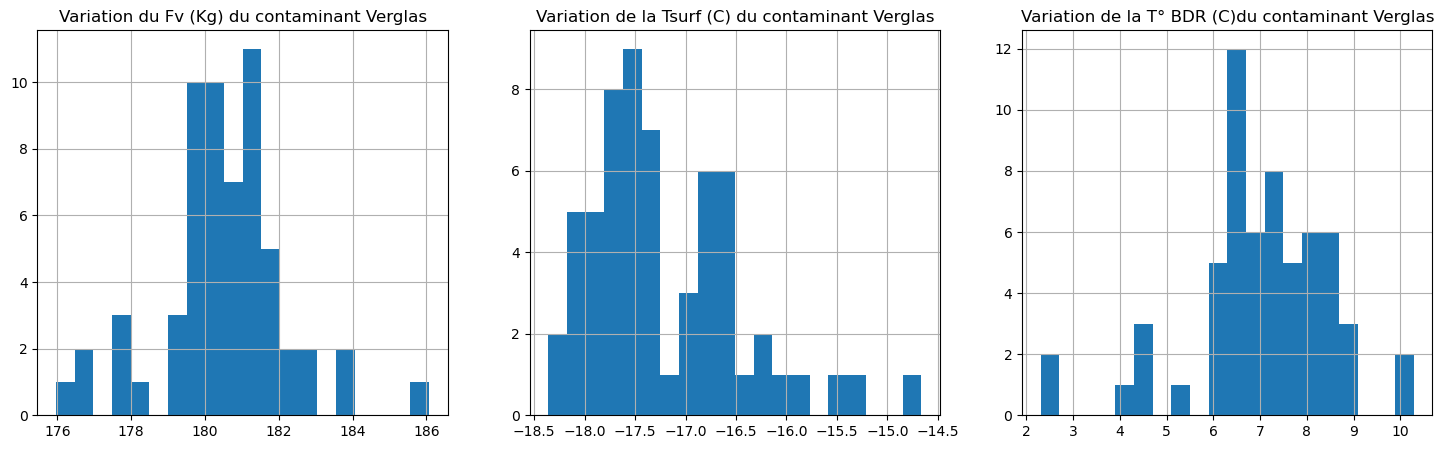

In [35]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
ver['Fv (kg)'].hist(bins=20)
plt.title('Variation du Fv (Kg) du contaminant Verglas')
plt.subplot(1,3,2)

ver['Tsurf (C)'].hist(bins=20)
plt.title('Variation de la Tsurf (C) du contaminant Verglas')
plt.subplot(1,3,3)
ver['T° BDR (C)'].hist(bins=20)
plt.title('Variation de la T° BDR (C)du contaminant Verglas')
plt.show()

### Modélisation linèaire sans transformation polynomiale

In [36]:
%%time
X = ver.drop(['Moyenne CFL C'], axis=1)
X = scale_encode(X,2)
y= ver['Moyenne CFL C']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = X.Vitesse_65, random_state=42)
regressor = LinearRegression()
regressor.fit(X_train, y_train)


coef(X, regressor)

Pour le test: RMSE = 0.02622, R² = -175.06, MAE = 0.02291
Pour le train: RMSE = 0.02431, R² = 65.36, MAE = 0.01883
          Feature Coefficient
0  Moyenne G% [%]    0.927508
1         Fv (kg)    2.724155
2       Tsurf (C)   -4.119264
3      T° BDR (C)    0.414890
4      Vitesse_65    0.011254
Intercept: -3.0506
CPU times: total: 15.6 ms
Wall time: 16 ms


### Ajout de coeft deg >1

In [37]:
def descritisation_verglas(x):
    if x<2:
        return "2"
    if x<5:
        return "5"
    if x<11:
        return "11"
    elif x< 13:
        return "13"
    elif x< 17:
        return "17"
    else:
        return "more"

In [38]:
X = ver.drop(['Moyenne CFL C','Fv (kg)',"T° BDR (C)","Tsurf (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_verglas)

#X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)

X["g2"] = X['Moyenne G% [%]']**(-0.2) # valeur recommandé -0.2

X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']


stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)

y= ver['Moyenne CFL C']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=stratify_combined, random_state=74)#24 42 74
regressor = LinearRegression()
regressor.fit(X_train, y_train)
        
        
coef(X, regressor)


Pour le test: RMSE = 0.01859, R² = 77.82, MAE = 0.01429
Pour le train: RMSE = 0.01989, R² = 71.95, MAE = 0.01658
          Feature Coefficient
0  Moyenne G% [%]   -0.000728
1      Vitesse_65    0.006248
2              g2   -0.251102
3             g*V   -0.000100
Intercept: 0.2994


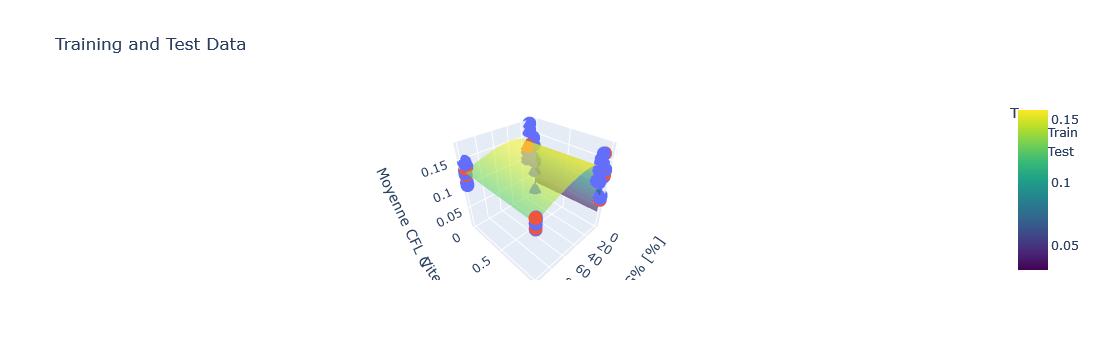

In [39]:
def scale_encode(x, y=0):
    encoder = OneHotEncoder(drop='first')
    # Séparer les variables qualitatives et numériques
    qualitative_vars = ['Vitesse']
    
    # Vérifier si les variables qualitatives sont dans le DataFrame
    if any(col not in x.columns for col in qualitative_vars):
        encoded_df = pd.DataFrame(index=x.index)  # Crée un DataFrame vide avec le même index
    else:
        # Appliquer le one-hot encoding aux variables qualitatives
        encoded_vars = encoder.fit_transform(x[qualitative_vars]).toarray()
        encoded_columns = encoder.get_feature_names_out(qualitative_vars)
        encoded_df = pd.DataFrame(encoded_vars, columns=encoded_columns, index=x.index)
    
    numeric_vars = x.select_dtypes(include=['float64', 'int64']).columns.tolist()
    
    if y == 1:  # Appliquer le StandardScaler aux variables numériques
        scaler = StandardScaler().set_output(transform='pandas')
    elif y == 2:  # Appliquer le Normalizer aux variables numériques
        scaler = Normalizer().set_output(transform='pandas')
    else:
        X = pd.concat([x.drop(qualitative_vars, axis=1, errors='ignore'), encoded_df], axis=1)
        return X
    
    # Appliquer le scaler et transformer les variables numériques
    scaled_df = scaler.fit_transform(x[numeric_vars])
    
    # Concaténation des DataFrames encodé et standardisé
    X = pd.concat([scaled_df, encoded_df], axis=1)
    return X









import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Préparation des données
X = ver.drop(['Moyenne CFL C', 'Fv (kg)', "T° BDR (C)", "Tsurf (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_verglas)
n=-0.2
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)

# X["g2"] = X['Moyenne G% [%]'] ** n
X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']

stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)

y = ver['Moyenne CFL C']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=stratify_combined, random_state=42)

# Entraîner le modèle de régression linéaire
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Choisissez deux variables indépendantes pour la visualisation 3D
feature_1 = 'Moyenne G% [%]'
feature_2 = 'Vitesse_65'

# Créez une grille de valeurs pour les variables indépendantes
x1_range = np.linspace(X[feature_1].min(), X[feature_1].max(), 100)
x2_range = np.linspace(X[feature_2].min(), X[feature_2].max(), 100)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# Construire la grille de données avec toutes les caractéristiques nécessaires
X_grid = pd.DataFrame({
    feature_1: x1_grid.ravel(),
    feature_2: x2_grid.ravel()
})

# Ajouter les caractéristiques supplémentaires
X_grid["log(g)"] = np.log(X_grid[feature_1])
X_grid["g2"] = X_grid[feature_1] ** n
X_grid["g*V"] = X_grid[feature_1] * X_grid[feature_2]

# Appliquer l'encodage et le scaling nécessaires
X_grid_transformed = scale_encode(X_grid, 0)

# Réorganiser les colonnes de X_grid_transformed pour correspondre à l'ordre des colonnes de X_train
X_grid_transformed = X_grid_transformed[X_train.columns]

# Utilisez le modèle pour prédire y sur la grille
y_pred_grid = regressor.predict(X_grid_transformed).reshape(x1_grid.shape)

# Préparez les données pour la visualisation 3D avec plotly.express
df_viz_train = pd.DataFrame({
    feature_1: X_train[feature_1],
    feature_2: X_train[feature_2],
    'Moyenne CFL C': y_train,
    'Type': 'Train'
})

df_viz_test = pd.DataFrame({
    feature_1: X_test[feature_1],
    feature_2: X_test[feature_2],
    'Moyenne CFL C': y_test,
    'Type': 'Test'
})

df_viz = pd.concat([df_viz_train, df_viz_test])

fig = px.scatter_3d(df_viz, x=feature_1, y=feature_2, z='Moyenne CFL C', color='Type', title='Training and Test Data')

# Ajoutez la surface de régression avec plotly.graph_objects
fig.add_trace(go.Surface(
    x=x1_grid,
    y=x2_grid,
    z=y_pred_grid,
    colorscale='Viridis',
    opacity=0.6,
    name='Regression Plane'
))

fig.show()


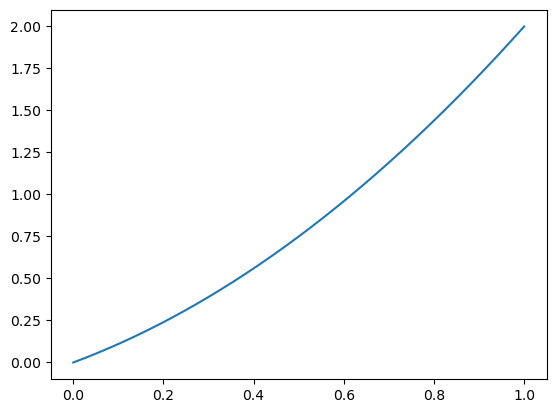

In [40]:
x = np.linspace(0,1,1000)
y= x + x**2 + 0*x**3
plt.plot(x,y)

In [41]:
y.describe()

AttributeError: 'numpy.ndarray' object has no attribute 'describe'

## Glace (122 observations)

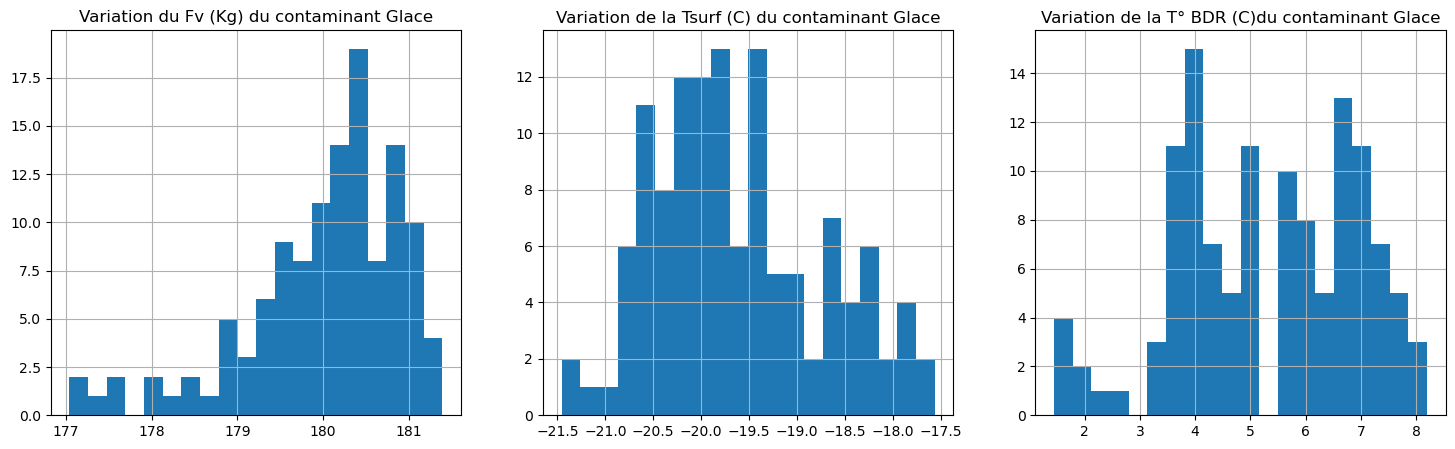

In [42]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
gla['Fv (kg)'].hist(bins=20)
plt.title('Variation du Fv (Kg) du contaminant Glace')
plt.subplot(1,3,2)

gla['Tsurf (C)'].hist(bins=20)
plt.title('Variation de la Tsurf (C) du contaminant Glace')
plt.subplot(1,3,3)
gla['T° BDR (C)'].hist(bins=20)
plt.title('Variation de la T° BDR (C)du contaminant Glace')
plt.show()

Ici contrairement aux précedent contaminant, on a une variabilité significative de la température de bande de roulement.

### Modélisation linèaire sans transformation polynomiale

In [ ]:
%%time
X = gla.drop(['Moyenne CFL C'], axis=1)
X = scale_encode(X,1)
y= gla['Moyenne CFL C']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify = X.Vitesse_65, random_state=123)
regressor = LinearRegression()
regressor.fit(X_train, y_train)


coef(X, regressor)

### Ajout de coeft deg >1

In [ ]:
def descritisation_glace(x):
    if x<3:
        return "3"
    if x<4:
        return "4"
    if x<6:
        return "6"
    if x<8:
        return "8"
    if x<11:
        return "11"
    elif x< 13:
        return "13"
    elif x< 15:
        return "15"
    elif x< 17:
        return "17"
    else:
        return "more"

In [ ]:
X = gla.drop(['Moyenne CFL C','Fv (kg)',"Tsurf (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_glace)

#X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)

X["g2"] = X['Moyenne G% [%]']**2
#X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']



stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)
y= gla['Moyenne CFL C']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify = stratify_combined, random_state=10)
regressor = LinearRegression()
regressor.fit(X_train, y_train)
    
    
coef(X, regressor)

#### Remarque T° BDR (C) (normalisation ameliore le modele) !!!!!!!!!!!!!!!!!

In [ ]:
y.describe()

In [ ]:
def scale_encode(x, y=0):
    encoder = OneHotEncoder(drop='first')
    # Séparer les variables qualitatives et numériques
    qualitative_vars = ['Vitesse']
    
    # Vérifier si les variables qualitatives sont dans le DataFrame
    if any(col not in x.columns for col in qualitative_vars):
        encoded_df = pd.DataFrame(index=x.index)  # Crée un DataFrame vide avec le même index
    else:
        # Appliquer le one-hot encoding aux variables qualitatives
        encoded_vars = encoder.fit_transform(x[qualitative_vars]).toarray()
        encoded_columns = encoder.get_feature_names_out(qualitative_vars)
        encoded_df = pd.DataFrame(encoded_vars, columns=encoded_columns, index=x.index)
    
    numeric_vars = x.select_dtypes(include=['float64', 'int64']).columns.tolist()
    
    if y == 1:  # Appliquer le StandardScaler aux variables numériques
        scaler = StandardScaler().set_output(transform='pandas')
    elif y == 2:  # Appliquer le Normalizer aux variables numériques
        scaler = Normalizer().set_output(transform='pandas')
    else:
        X = pd.concat([x.drop(qualitative_vars, axis=1, errors='ignore'), encoded_df], axis=1)
        return X
    
    # Appliquer le scaler et transformer les variables numériques
    scaled_df = scaler.fit_transform(x[numeric_vars])
    
    # Concaténation des DataFrames encodé et standardisé
    X = pd.concat([scaled_df, encoded_df], axis=1)
    return X









import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Préparation des données
X = gla.drop(['Moyenne CFL C', 'Fv (kg)', "T° BDR (C)", "Tsurf (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_glace)
n=-0.2
# X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)

X["g2"] = X['Moyenne G% [%]'] ** n
X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']

stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)

y = gla['Moyenne CFL C']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=stratify_combined, random_state=42)

# Entraîner le modèle de régression linéaire
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Choisissez deux variables indépendantes pour la visualisation 3D
feature_1 = 'Moyenne G% [%]'
feature_2 = 'Vitesse_65'

# Créez une grille de valeurs pour les variables indépendantes
x1_range = np.linspace(X[feature_1].min(), X[feature_1].max(), 100)
x2_range = np.linspace(X[feature_2].min(), X[feature_2].max(), 100)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# Construire la grille de données avec toutes les caractéristiques nécessaires
X_grid = pd.DataFrame({
    feature_1: x1_grid.ravel(),
    feature_2: x2_grid.ravel()
})

# Ajouter les caractéristiques supplémentaires
# X_grid["log(g)"] = np.log(X_grid[feature_1])
X_grid["g2"] = X_grid[feature_1] ** n
X_grid["g*V"] = X_grid[feature_1] * X_grid[feature_2]

# Appliquer l'encodage et le scaling nécessaires
X_grid_transformed = scale_encode(X_grid, 0)

# Réorganiser les colonnes de X_grid_transformed pour correspondre à l'ordre des colonnes de X_train
X_grid_transformed = X_grid_transformed[X_train.columns]

# Utilisez le modèle pour prédire y sur la grille
y_pred_grid = regressor.predict(X_grid_transformed).reshape(x1_grid.shape)

# Préparez les données pour la visualisation 3D avec plotly.express
df_viz_train = pd.DataFrame({
    feature_1: X_train[feature_1],
    feature_2: X_train[feature_2],
    'Moyenne CFL C': y_train,
    'Type': 'Train'
})

df_viz_test = pd.DataFrame({
    feature_1: X_test[feature_1],
    feature_2: X_test[feature_2],
    'Moyenne CFL C': y_test,
    'Type': 'Test'
})

df_viz = pd.concat([df_viz_train, df_viz_test])

fig = px.scatter_3d(df_viz, x=feature_1, y=feature_2, z='Moyenne CFL C', color='Type', title='Training and Test Data')

# Ajoutez la surface de régression avec plotly.graph_objects
fig.add_trace(go.Surface(
    x=x1_grid,
    y=x2_grid,
    z=y_pred_grid,
    colorscale='Viridis',
    opacity=0.6,
    name='Regression Plane'
))

fig.show()
gla

## SLUSH (85 observations)

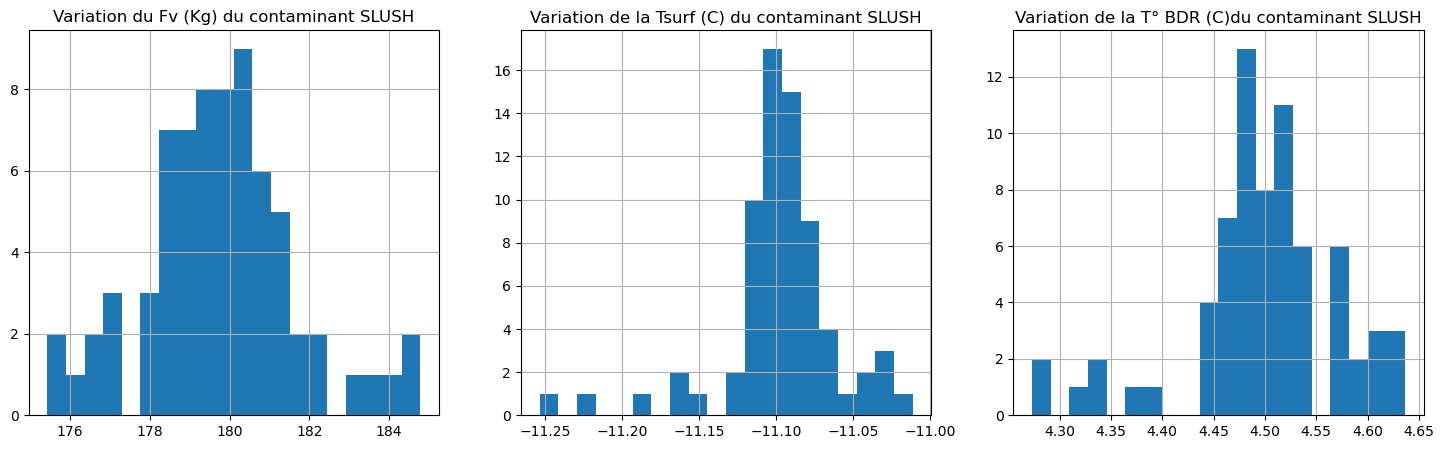

In [43]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
slh['Fv (kg)'].hist(bins=20)
plt.title('Variation du Fv (Kg) du contaminant SLUSH')
plt.subplot(1,3,2)

slh['Tsurf (C)'].hist(bins=20)
plt.title('Variation de la Tsurf (C) du contaminant SLUSH')
plt.subplot(1,3,3)
slh['T° BDR (C)'].hist(bins=20)
plt.title('Variation de la T° BDR (C)du contaminant SLUSH')
plt.show()

### Modélisation linèaire sans transformation polynomiale

In [ ]:
%%time
X = slh.drop(['Moyenne CFL C'], axis=1)
X = scale_encode(X,2)
y= slh['Moyenne CFL C']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify = X.Vitesse_65, random_state=123)
regressor = LinearRegression()
regressor.fit(X_train, y_train)


coef(X, regressor)

### Ajout de coeft deg >1

In [ ]:
def descritisation_slh(x):
    if x<0.5:
        return "0.5"
    if x<1:
        return "1"
    if x<4:
        return "4"

    elif x< 14:
        return "14"
    else:
        return "more"


In [ ]:
X = slh.drop(['Moyenne CFL C','Fv (kg)',"Tsurf (C)", "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_slh)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)

X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']


stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)

y= slh['Moyenne CFL C']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify = stratify_combined, random_state=16)#2 16   29   68
regressor = LinearRegression()
regressor.fit(X_train, y_train)
    
    
coef(X, regressor)

In [ ]:
y.describe()

## DRY (19 observations)

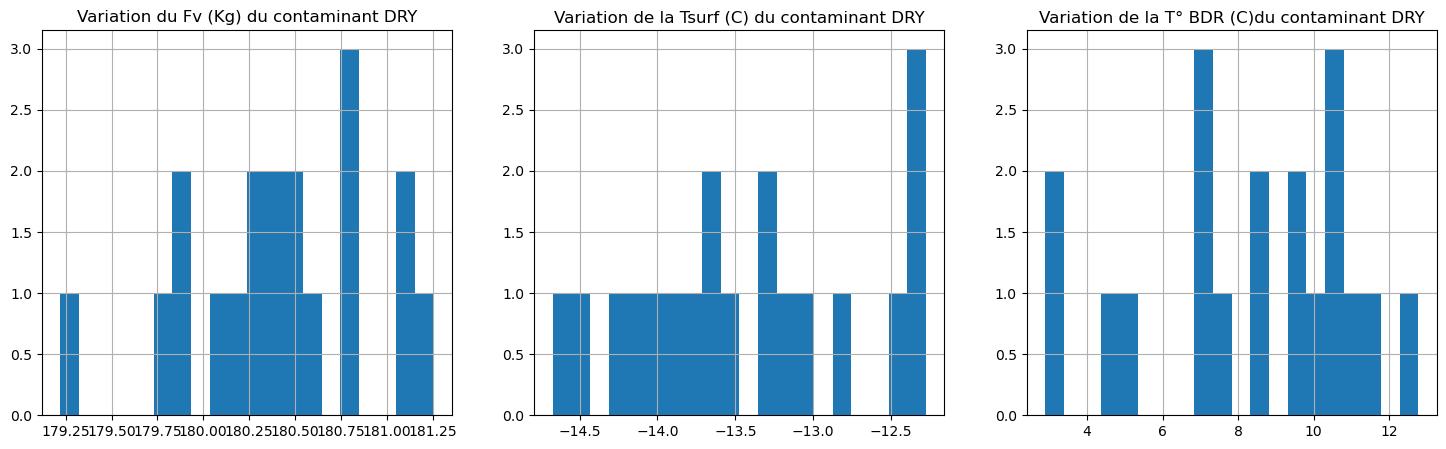

In [44]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
dry['Fv (kg)'].hist(bins=20)
plt.title('Variation du Fv (Kg) du contaminant DRY')
plt.subplot(1,3,2)

dry['Tsurf (C)'].hist(bins=20)
plt.title('Variation de la Tsurf (C) du contaminant DRY')
plt.subplot(1,3,3)
dry['T° BDR (C)'].hist(bins=20)
plt.title('Variation de la T° BDR (C)du contaminant DRY')
plt.show()

### Modélisation linèaire sans transformation polynomiale

In [ ]:
%%time
X = dry.drop(['Moyenne CFL C'], axis=1)
X = scale_encode(X,2)
y= dry['Moyenne CFL C']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify = X.Vitesse_65, random_state=42)
regressor = LinearRegression()
regressor.fit(X_train, y_train)


coef(X, regressor)

### Ajout de coeft deg >1

In [ ]:
X = dry.drop(['Moyenne CFL C','Fv (kg)',"Tsurf (C)", "T° BDR (C)"], axis=1)
# X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)

X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']



# Soit choisir le log le carré (le carré explique bien une relation lineaire)
y = dry["Moyenne CFL C"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify = X.Vitesse_65, random_state=123)
regressor = LinearRegression()
regressor.fit(X_train, y_train)


coef(X, regressor)

In [ ]:
y.describe()

# Fin modelisation lineaire

# Modelisation de la relation entre T Bdr et la vitesse, glissement et T_surf

In [ ]:
def scale_encode(x,y = 0,oui="n"):
    encoder = OneHotEncoder(drop='first')
    # Séparer les variables qualitatives et numériques
    qualitative_vars = ['Vitesse', "Contaminant"] if oui == "o" else ['Vitesse']
    numeric_vars = x.select_dtypes(include=['float']).columns.tolist()
    
    # Appliquer le one-hot encoding aux variables qualitatives
    encoded_vars = encoder.fit_transform(x[qualitative_vars]).toarray()
    encoded_columns = encoder.get_feature_names_out(qualitative_vars)
    encoded_df = pd.DataFrame(encoded_vars, columns=encoded_columns)
    if y == 1:  # Appliquer le StandardScaler aux variables numériques
        scaler = StandardScaler().set_output(transform='pandas')
    elif y == 2:  # Appliquer le Normalizer aux variables numériques
        scaler = Normalizer().set_output(transform='pandas')
    else:
        X = pd.concat([x.drop(qualitative_vars, axis=1), encoded_df], axis=1)
        return X
    
    # Appliquer le scaler et transformer les variables numériques
    scaled_df = scaler.fit_transform(x[numeric_vars])
    
    # Concaténation des DataFrames encodé et standardisé
    X = pd.concat([scaled_df, encoded_df], axis=1)
    return X

## Modele g+T+V + Contamianant

In [ ]:
T = df[['Vitesse','Moyenne G% [%]','Tsurf (C)', 'T° BDR (C)', "Contaminant"]].copy()
X = T.drop(['T° BDR (C)'], axis = 1)
X = scale_encode(X,0,"o")
y = T['T° BDR (C)']




#X=X.drop(['Moyenne G% [%]',"Vitesse_65"], axis = 1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify= X["Vitesse_65"],random_state=123)
regressor = LinearRegression()
regressor.fit(X_train, y_train)


coef(X, regressor)

## modele (alpha * V + beta * V*g) * T

In [ ]:
T = df[['Vitesse','Moyenne G% [%]','Tsurf (C)', 'T° BDR (C)']].copy()
X = T.drop(['T° BDR (C)'], axis = 1)
X = scale_encode(X,1)
y = T['T° BDR (C)']



X["V*T"] = X['Vitesse_65']*X['Tsurf (C)']
X["V*g"] = X['Vitesse_65']*X['Moyenne G% [%]']
X["V*g*T"] = X['Vitesse_65']*X['Moyenne G% [%]']*X['Tsurf (C)']

#X=X.drop(['Moyenne G% [%]',"Tsurf (C)","Vitesse_65"], axis = 1)
X=X.drop(["Vitesse_65",'Moyenne G% [%]'], axis = 1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
regressor = LinearRegression()
regressor.fit(X_train, y_train)


coef(X, regressor)

## Modele g+T+V + Contamianant + VT +VgT

## Modele Contamianant

In [ ]:
T = df[['Vitesse','Moyenne G% [%]','Tsurf (C)', 'T° BDR (C)',"Contaminant"]].copy()
X = T.drop(['T° BDR (C)'], axis = 1)
X = scale_encode(X,0,"o")
y = T['T° BDR (C)']




X=X.drop(['Moyenne G% [%]',"Vitesse_65",'Tsurf (C)'], axis = 1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=123)
regressor = LinearRegression()
regressor.fit(X_train, y_train)


coef(X, regressor)

## Contaminant par cantaminant

In [ ]:
# Neige fraiche (B)
df1 = X_o[X_o.Contaminant == 'Neige fraiche (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Neige fraiche (G)
df2 = X_o[X_o.Contaminant == 'Neige fraiche (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (G)
df3 = X_o[X_o.Contaminant == 'N.C. (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (B)
df4 = X_o[X_o.Contaminant == 'N.C. (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# NC.C.
df5 = X_o[X_o.Contaminant == 'NC.C.'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Verglas
df6 = X_o[X_o.Contaminant == 'Verglas'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# DRY
df7 = X_o[X_o.Contaminant == 'DRY'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Glace
df8 = X_o[X_o.Contaminant == 'Glace'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# SLUSH
df9 = X_o[X_o.Contaminant == 'SLUSH'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Columns to drop in every modele


In [ ]:
for i in range(1,10):
    T = globals()[f"df{i}"][['Vitesse','Moyenne G% [%]','Tsurf (C)', 'T° BDR (C)']].copy()
    X = T.drop(['T° BDR (C)'], axis = 1)
    X = scale_encode(X,0)
    X["V*T"] = X['Vitesse_65']*X['Tsurf (C)']
    X["V*g"] = X['Vitesse_65']*X['Moyenne G% [%]']
    X["V*g*T"] = X['Vitesse_65']*X['Moyenne G% [%]']*X['Tsurf (C)']
    y = T['T° BDR (C)']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify= X["Vitesse_65"],random_state=123)
    regressor = LinearRegression()
    regressor.fit(X_train, y_train)
    coef(X, regressor)




#X=X.drop(['Moyenne G% [%]',"Vitesse_65"], axis = 1)

